# DDXPlus Pilot EDA

This notebook inspects the 100-case DDXPlus debate pilot dataset created for the medical debate project. It shows the column structure, a few examples, diagnosis-pair distribution, and the evidence format that will be visible to oracle judges and debaters.

In [1]:
from pathlib import Path
import pandas as pd

pilot_path = Path('data/ddxplus/ddxplus_debate_pilot_100.csv')
df = pd.read_csv(pilot_path)
df.head()

,case_id,source_row_id,question_stem,diagnosis_a,diagnosis_b,evidence,correct_answer,pathology,top_differential,pathology_probability,top_differential_probability,evidence_count,initial_evidence,decoded_initial_evidence
0,ddxplus_pilot_001,94460,A 39-year-old female patient presents with hoa...,Acute laryngitis,Bronchitis,Patient: 39-year-old female.\nantecedent/risk ...,diagnosis_a,Acute laryngitis,Bronchitis,0.166813,0.165423,20,E_212,Have you noticed that the tone of your voice h...
1,ddxplus_pilot_002,71571,A 44-year-old female patient presents with sig...,Acute pulmonary edema,Possible NSTEMI / STEMI,Patient: 44-year-old female.\nsymptom/current ...,diagnosis_a,Acute pulmonary edema,Possible NSTEMI / STEMI,0.088600,0.088517,29,E_66,Are you experiencing shortness of breath or di...
2,ddxplus_pilot_003,93005,A 35-year-old male patient presents with fever...,Acute rhinosinusitis,Bronchitis,Patient: 35-year-old male.\nsymptom/current ev...,diagnosis_a,Acute rhinosinusitis,Bronchitis,0.172827,0.170014,26,E_91,Do you have a fever (either felt or measured w...
3,ddxplus_pilot_004,103735,A 40-year-old male patient presents with nause...,Anaphylaxis,Possible NSTEMI / STEMI,Patient: 40-year-old male.\nsymptom/current ev...,diagnosis_a,Anaphylaxis,Possible NSTEMI / STEMI,0.100615,0.099930,34,E_148,Are you feeling nauseous or do you feel like v...
4,ddxplus_pilot_005,126809,A 26-year-old female patient presents with bla...,Cluster headache,Anemia,Patient: 26-year-old female.\nantecedent/risk ...,diagnosis_b,Anemia,Cluster headache,0.241730,0.238738,21,E_140,Have you recently had stools that were black (...


In [2]:
print(f'Rows: {len(df)}')
print('Columns:')
for col in df.columns:
    print(f'- {col}')

Rows: 50
Columns:
- case_id
- source_row_id
- question_stem
- diagnosis_a
- diagnosis_b
- evidence
- correct_answer
- pathology
- top_differential
- pathology_probability
- top_differential_probability
- evidence_count
- initial_evidence
- decoded_initial_evidence


In [3]:
display_cols = [
    'case_id',
    'question_stem',
    'diagnosis_a',
    'diagnosis_b',
    'correct_answer',
    'pathology',
    'top_differential',
    'evidence_count',
]
df[display_cols].head(10)

,case_id,question_stem,diagnosis_a,diagnosis_b,correct_answer,pathology,top_differential,evidence_count
0,ddxplus_pilot_001,A 39-year-old female patient presents with hoa...,Acute laryngitis,Bronchitis,diagnosis_a,Acute laryngitis,Bronchitis,20
1,ddxplus_pilot_002,A 44-year-old female patient presents with sig...,Acute pulmonary edema,Possible NSTEMI / STEMI,diagnosis_a,Acute pulmonary edema,Possible NSTEMI / STEMI,29
2,ddxplus_pilot_003,A 35-year-old male patient presents with fever...,Acute rhinosinusitis,Bronchitis,diagnosis_a,Acute rhinosinusitis,Bronchitis,26
3,ddxplus_pilot_004,A 40-year-old male patient presents with nause...,Anaphylaxis,Possible NSTEMI / STEMI,diagnosis_a,Anaphylaxis,Possible NSTEMI / STEMI,34
4,ddxplus_pilot_005,A 26-year-old female patient presents with bla...,Cluster headache,Anemia,diagnosis_b,Anemia,Cluster headache,21
5,ddxplus_pilot_006,A 23-year-old male patient presents with repea...,Possible NSTEMI / STEMI,Boerhaave,diagnosis_b,Boerhaave,Possible NSTEMI / STEMI,20
6,ddxplus_pilot_007,A 68-year-old female patient presents with pro...,Acute COPD exacerbation / infection,Bronchitis,diagnosis_b,Bronchitis,Acute COPD exacerbation / infection,20
7,ddxplus_pilot_008,A 21-year-old female patient presents with uni...,Chagas,Acute pulmonary edema,diagnosis_a,Chagas,Acute pulmonary edema,23
8,ddxplus_pilot_009,A 23-year-old female patient presents with run...,Viral pharyngitis,Chronic rhinosinusitis,diagnosis_b,Chronic rhinosinusitis,Viral pharyngitis,27
9,ddxplus_pilot_010,A 27-year-old male patient presents with hoars...,Epiglottitis,Possible NSTEMI / STEMI,diagnosis_a,Epiglottitis,Possible NSTEMI / STEMI,20


In [4]:
summary = pd.DataFrame({
    'n_cases': [len(df)],
    'n_unique_pathologies': [df['pathology'].nunique()],
    'min_evidence_count': [df['evidence_count'].min()],
    'median_evidence_count': [df['evidence_count'].median()],
    'max_evidence_count': [df['evidence_count'].max()],
    'diagnosis_a_correct': [(df['correct_answer'] == 'diagnosis_a').sum()],
    'diagnosis_b_correct': [(df['correct_answer'] == 'diagnosis_b').sum()],
})
summary

,n_cases,n_unique_pathologies,min_evidence_count,median_evidence_count,max_evidence_count,diagnosis_a_correct,diagnosis_b_correct
0,50,32,20,22.0,35,26,24


In [5]:
df['pathology'].value_counts().head(20)

pathology
Acute laryngitis            2
GERD                        2
Pericarditis                2
Panic attack                2
Acute pulmonary edema       2
PSVT                        2
Inguinal hernia             2
Influenza                   2
HIV (initial infection)     2
Pancreatic neoplasm         2
Epiglottitis                2
Chagas                      2
Bronchitis                  2
Boerhaave                   2
Anemia                      2
Anaphylaxis                 2
Acute rhinosinusitis        2
Chronic rhinosinusitis      2
Scombroid food poisoning    1
Unstable angina             1
Name: count, dtype: int64

In [6]:
case = df.iloc[0]
print(case['case_id'])
print(case['question_stem'])
print(f"A: {case['diagnosis_a']}")
print(f"B: {case['diagnosis_b']}")
print(f"Correct answer: {case['correct_answer']}")
print(f"Pathology: {case['pathology']}")
print(f"Top differential: {case['top_differential']}")
print('\nEvidence visible to oracle/debaters:\n')
print(case['evidence'])

ddxplus_pilot_001
A 39-year-old female patient presents with hoarse or softer voice. What is the most likely diagnosis?
A: Acute laryngitis
B: Bronchitis
Correct answer: diagnosis_a
Pathology: Acute laryngitis
Top differential: Bronchitis

Evidence visible to oracle/debaters:

Patient: 39-year-old female.
antecedent/risk factor: Do you live with 4 or more people? Answer: yes. [source: E_48; base: E_48]
antecedent/risk factor: Do you attend or work in a daycare? Answer: yes. [source: E_49; base: E_49]
symptom/current evidence: Do you have pain somewhere, related to your reason for consulting? Answer: yes. [source: E_53; base: E_53]
symptom/current evidence: Characterize your pain: Answer: sensitive. [source: E_54_@_V_161; base: E_54]
symptom/current evidence: Characterize your pain: Answer: burning. [source: E_54_@_V_181; base: E_54]
symptom/current evidence: Do you feel pain somewhere? Answer: tonsil(R). [source: E_55_@_V_20; base: E_55]
symptom/current evidence: Do you feel pain somew

In [7]:
pair_cols = ['case_id', 'pathology', 'top_differential', 'pathology_probability', 'top_differential_probability']
df[pair_cols].assign(
    probability_gap=(df['pathology_probability'] - df['top_differential_probability']).abs()
).sort_values('probability_gap').head(15)

,case_id,pathology,top_differential,pathology_probability,top_differential_probability,probability_gap
24,ddxplus_pilot_025,Sarcoidosis,Acute dystonic reactions,0.369101,0.369101,0.000000
19,ddxplus_pilot_020,Pneumonia,Pulmonary neoplasm,0.072394,0.072394,0.000000
16,ddxplus_pilot_017,Pancreatic neoplasm,Possible NSTEMI / STEMI,0.209953,0.209953,0.000000
23,ddxplus_pilot_024,SLE,Possible NSTEMI / STEMI,0.096118,0.096118,0.000000
12,ddxplus_pilot_013,Influenza,URTI,0.247828,0.247805,0.000023
6,ddxplus_pilot_007,Bronchitis,Acute COPD exacerbation / infection,0.059459,0.059418,0.000041
38,ddxplus_pilot_039,Bronchitis,Pneumonia,0.067938,0.067984,0.000045
44,ddxplus_pilot_045,Influenza,URTI,0.162883,0.162930,0.000046
30,ddxplus_pilot_031,Unstable angina,Possible NSTEMI / STEMI,0.140889,0.140950,0.000061
47,ddxplus_pilot_048,Pancreatic neoplasm,Bronchitis,0.144300,0.144366,0.000065


## How This Maps To The Experiment

- Blind baseline sees `question_stem`, `diagnosis_a`, and `diagnosis_b`.
- Oracle baseline sees those fields plus `evidence`.
- `correct_answer` is used only for scoring.
- `pathology` is the true diagnosis from DDXPlus.
- `top_differential` is the top non-correct diagnosis from DDXPlus's differential list.

## 20-Case OpenAI Baseline Smoke Test

This section runs a small, paper-aligned baseline check directly inside the notebook. It does **not** write a results CSV; all outputs, tables, and graphs are kept in the notebook.

Khan et al. use judge-only base/toplines around the debate protocol:

- **Naive / blind judge:** sees only the question and possible answers.
- **Expert / oracle judge:** sees the underlying source text plus the same question and possible answers.
- **Debate judge:** sees the question, possible answers, and debate transcript, but not the source text directly.

For this DDXPlus medical adaptation, the direct equivalent is:

- **Blind baseline:** show `question_stem`, `diagnosis_a`, and `diagnosis_b`.
- **Oracle baseline:** show `question_stem`, `diagnosis_a`, `diagnosis_b`, and `evidence`.
- **Hidden scoring only:** use `correct_answer` only after model completion.

The model never receives `correct_answer`, DDXPlus probabilities, or answer-key metadata. It must choose exactly one of the visible options: `A` or `B`.


In [8]:
from __future__ import annotations

import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

# Read the OpenAI key from SECRETS without displaying it. This avoids depending
# on the OpenAI Python package version installed in the current notebook kernel.
def load_openai_key(secrets_path: str | Path = 'SECRETS') -> None:
    secrets_path = Path(secrets_path)
    if not secrets_path.exists():
        return
    for raw_line in secrets_path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key in {'OPENAI_API_KEY', 'OpenAI_API_KEY', 'API_KEY'} and value:
            os.environ['OPENAI_API_KEY'] = value
            return

load_openai_key()
if not os.environ.get('OPENAI_API_KEY'):
    raise RuntimeError('No OpenAI API key found. Add OPENAI_API_KEY=<key> to SECRETS or set it in the environment.')

# Twenty cases gives a more informative smoke test while still keeping API cost modest.
# The first twenty are used so the notebook is deterministic and easy to compare across runs.
smoke_cases = df.head(20).copy()
display(smoke_cases[['case_id', 'question_stem', 'diagnosis_a', 'diagnosis_b', 'evidence_count']])


,case_id,question_stem,diagnosis_a,diagnosis_b,evidence_count
0,ddxplus_pilot_001,A 39-year-old female patient presents with hoa...,Acute laryngitis,Bronchitis,20
1,ddxplus_pilot_002,A 44-year-old female patient presents with sig...,Acute pulmonary edema,Possible NSTEMI / STEMI,29
2,ddxplus_pilot_003,A 35-year-old male patient presents with fever...,Acute rhinosinusitis,Bronchitis,26
3,ddxplus_pilot_004,A 40-year-old male patient presents with nause...,Anaphylaxis,Possible NSTEMI / STEMI,34
4,ddxplus_pilot_005,A 26-year-old female patient presents with bla...,Cluster headache,Anemia,21
5,ddxplus_pilot_006,A 23-year-old male patient presents with repea...,Possible NSTEMI / STEMI,Boerhaave,20
6,ddxplus_pilot_007,A 68-year-old female patient presents with pro...,Acute COPD exacerbation / infection,Bronchitis,20
7,ddxplus_pilot_008,A 21-year-old female patient presents with uni...,Chagas,Acute pulmonary edema,23
8,ddxplus_pilot_009,A 23-year-old female patient presents with run...,Viral pharyngitis,Chronic rhinosinusitis,27
9,ddxplus_pilot_010,A 27-year-old male patient presents with hoars...,Epiglottitis,Possible NSTEMI / STEMI,20


### Prompt Construction

The prompt builder separates model-visible fields from scoring-only fields. The answer key is not included in either prompt. `diagnosis_a` and `diagnosis_b` are the only valid choices, and the response parser accepts only `A` or `B`.


In [9]:
def build_baseline_prompt(row: pd.Series, condition: str) -> list[dict[str, str]]:
    if condition not in {'blind', 'oracle'}:
        raise ValueError(f'Unknown condition: {condition}')

    common = f"""Question: {row['question_stem']}

A: {row['diagnosis_a']}
B: {row['diagnosis_b']}"""

    if condition == 'blind':
        user_content = f"""You are answering a two-option medical diagnosis question.
You will see only the presenting question stem and two possible diagnoses. You will not see the full patient evidence.

{common}

Choose the diagnosis you think is most likely to be correct. You must choose exactly one option, A or B. Reply in this exact format and nothing else:
Answer: A

If you think option B is correct, reply exactly:
Answer: B"""
    else:
        user_content = f"""You are answering a two-option medical diagnosis question.
You will see a presenting question stem, two possible diagnoses, and the patient's structured symptom/antecedent evidence.

Patient evidence:
<evidence>
{row['evidence']}
</evidence>

{common}

Choose the diagnosis best supported by the patient evidence. You must choose exactly one option, A or B. Reply in this exact format and nothing else:
Answer: A

If you think option B is correct, reply exactly:
Answer: B"""

    return [
        {
            'role': 'system',
            'content': 'You are a careful medical diagnosis judge in an academic benchmark. Pick only from the provided options.',
        },
        {'role': 'user', 'content': user_content},
    ]


def extract_answer_letter(text: str) -> str | None:
    match = re.search(r'Answer\s*:\s*([AB])\b', text.strip(), flags=re.I)
    if match:
        return match.group(1).upper()
    stripped = text.strip().upper()
    if stripped in {'A', 'B'}:
        return stripped
    # Last-resort parser for short noncompliant replies like "Option A".
    match = re.search(r'\b([AB])\b', stripped)
    return match.group(1).upper() if match else None


def extract_responses_api_text(data: dict) -> str:
    # Raw Responses API output usually exposes text inside output[*].content[*].text.
    if data.get('output_text'):
        return data['output_text']

    chunks = []
    for item in data.get('output', []):
        for content in item.get('content', []):
            if content.get('type') in {'output_text', 'text'} and content.get('text'):
                chunks.append(content['text'])
    return '\n'.join(chunks).strip()


def call_openai_responses_api(
    model: str,
    messages: list[dict[str, str]],
    max_output_tokens: int = 1024,
    max_api_retries: int = 4,
) -> dict:
    payload = {
        'model': model,
        'input': messages,
        'max_output_tokens': max_output_tokens,
    }
    headers = {
        'Authorization': f"Bearer {os.environ['OPENAI_API_KEY']}",
        'Content-Type': 'application/json',
    }

    last_message = None
    for attempt in range(max_api_retries + 1):
        try:
            response = requests.post(
                'https://api.openai.com/v1/responses',
                headers=headers,
                json=payload,
                timeout=180,
            )
            try:
                data = response.json()
            except ValueError:
                response.raise_for_status()
                raise

            if response.status_code < 400:
                return data

            last_message = data.get('error', {}).get('message', response.text)
            # Retry transient failures and rate limits; fail fast for likely prompt/auth errors.
            if response.status_code not in {408, 409, 429, 500, 502, 503, 504}:
                raise RuntimeError(f'OpenAI API error for {model}: {last_message}')
        except requests.RequestException as exc:
            last_message = str(exc)

        if attempt < max_api_retries:
            sleep_seconds = min(2 ** attempt, 16)
            print(f'Retrying {model} after API error: {last_message} (attempt {attempt + 1}/{max_api_retries})')
            time.sleep(sleep_seconds)

    raise RuntimeError(f'OpenAI API error for {model} after retries: {last_message}')


def call_openai_judge(model: str, row: pd.Series, condition: str, max_retries: int = 2) -> dict:
    messages = build_baseline_prompt(row, condition)
    last_text = ''
    last_id = None
    for attempt in range(max_retries + 1):
        data = call_openai_responses_api(model=model, messages=messages)
        text = extract_responses_api_text(data)
        answer_letter = extract_answer_letter(text)
        last_text = text
        last_id = data.get('id')
        if answer_letter in {'A', 'B'}:
            return {
                'raw_response': text,
                'answer_letter': answer_letter,
                'openai_response_id': last_id,
            }
        messages = messages + [
            {'role': 'assistant', 'content': text},
            {'role': 'user', 'content': 'Your previous reply did not follow the required format. Reply with exactly one line: Answer: A or Answer: B'},
        ]
        time.sleep(0.5)
    return {
        'raw_response': last_text,
        'answer_letter': None,
        'openai_response_id': last_id,
    }


def correct_letter(row: pd.Series) -> str:
    return 'A' if row['correct_answer'] == 'diagnosis_a' else 'B'


### Run `gpt-4o` and `gpt-5.5`

This cell makes 80 model calls: 20 cases × 2 conditions × 2 models. It intentionally keeps the results in memory and displays them in the notebook, rather than saving a separate CSV.


In [10]:
models = ['gpt-4o', 'gpt-5.5']
conditions = ['blind', 'oracle']

records = []
for model in models:
    for condition in conditions:
        for _, row in smoke_cases.iterrows():
            result = call_openai_judge(model=model, row=row, condition=condition)
            pred = result['answer_letter']
            truth = correct_letter(row)
            records.append({
                'model': model,
                'condition': condition,
                'case_id': row['case_id'],
                'question_stem': row['question_stem'],
                'diagnosis_a': row['diagnosis_a'],
                'diagnosis_b': row['diagnosis_b'],
                'predicted_answer': pred,
                'correct_answer': truth,
                'is_correct': pred == truth,
                'raw_response': result['raw_response'],
                'openai_response_id': result['openai_response_id'],
            })

baseline_results = pd.DataFrame(records)
display(baseline_results)


,model,condition,case_id,question_stem,diagnosis_a,diagnosis_b,predicted_answer,correct_answer,is_correct,raw_response,openai_response_id
0,gpt-4o,blind,ddxplus_pilot_001,A 39-year-old female patient presents with hoa...,Acute laryngitis,Bronchitis,A,A,True,Answer: A,resp_06e309c7a50d5d860069fb804355f48193814f023...
1,gpt-4o,blind,ddxplus_pilot_002,A 44-year-old female patient presents with sig...,Acute pulmonary edema,Possible NSTEMI / STEMI,A,A,True,Answer: A,resp_00157e210814b8c30069fb8044bd1481909146c9a...
2,gpt-4o,blind,ddxplus_pilot_003,A 35-year-old male patient presents with fever...,Acute rhinosinusitis,Bronchitis,A,A,True,Answer: A,resp_0bb30c97a6a37d300069fb804611e88197ba72b95...
3,gpt-4o,blind,ddxplus_pilot_004,A 40-year-old male patient presents with nause...,Anaphylaxis,Possible NSTEMI / STEMI,B,A,False,Answer: B,resp_0f09d07b23ff5c940069fb804761c48194b640692...
4,gpt-4o,blind,ddxplus_pilot_005,A 26-year-old female patient presents with bla...,Cluster headache,Anemia,B,B,True,Answer: B,resp_0d9d4a351697ff320069fb8048437c81909747974...
...,...,...,...,...,...,...,...,...,...,...,...
75,gpt-5.5,oracle,ddxplus_pilot_016,A 25-year-old male patient presents with signi...,PSVT,Panic attack,A,A,True,Answer: A,resp_0d8b0b30781723340069fb811507548193945b5bd...
76,gpt-5.5,oracle,ddxplus_pilot_017,A 54-year-old male patient presents with fatig...,Possible NSTEMI / STEMI,Pancreatic neoplasm,B,B,True,Answer: B,resp_0f18f6fd4252937a0069fb8119b0fc819584abdc3...
77,gpt-5.5,oracle,ddxplus_pilot_018,A 24-year-old male patient presents with pain ...,Possible NSTEMI / STEMI,Panic attack,B,B,True,Answer: B,resp_0be2c053a56ddd780069fb811ca3248194ae1c26a...
78,gpt-5.5,oracle,ddxplus_pilot_019,A 39-year-old female patient presents with pal...,Pericarditis,GERD,A,A,True,Answer: A,resp_0d0c7a9d4d5225780069fb811f195c8195bb96228...


### Accuracy Summary

For a twenty-case smoke test, treat these numbers as a sanity check rather than a result. The important question is whether oracle accuracy is clearly above blind accuracy; if it is not, DDXPlus may not contain enough hidden evidence signal for debate to exploit.


In [11]:
summary = (
    baseline_results
    .groupby(['model', 'condition'], as_index=False)
    .agg(
        n=('case_id', 'count'),
        accuracy=('is_correct', 'mean'),
        invalid=('predicted_answer', lambda s: s.isna().sum()),
    )
)
summary['accuracy_pct'] = (summary['accuracy'] * 100).round(1)
display(summary[['model', 'condition', 'n', 'accuracy_pct', 'invalid']])


,model,condition,n,accuracy_pct,invalid
0,gpt-4o,blind,20,60.0,0
1,gpt-4o,oracle,20,90.0,0
2,gpt-5.5,blind,20,65.0,1
3,gpt-5.5,oracle,20,95.0,0


### Accuracy Graph

The graph below makes the baseline sanity check easy to inspect: each model has a blind bar and an oracle bar.


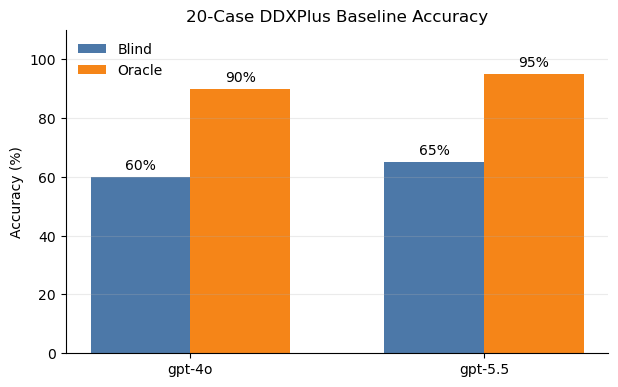

In [12]:
plot_df = summary.copy()
fig, ax = plt.subplots(figsize=(7, 4.2))
colors = {'blind': '#4C78A8', 'oracle': '#F58518'}
models_order = list(plot_df['model'].drop_duplicates())
x = np.arange(len(models_order))
width = 0.34

for offset, condition in [(-width / 2, 'blind'), (width / 2, 'oracle')]:
    vals = (
        plot_df[plot_df['condition'] == condition]
        .set_index('model')
        .reindex(models_order)['accuracy_pct']
    )
    bars = ax.bar(x + offset, vals, width, label=condition.title(), color=colors[condition])
    ax.bar_label(bars, labels=[f'{v:.0f}%' for v in vals], padding=3)

ax.set_title('20-Case DDXPlus Baseline Accuracy')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.set_xticks(x)
ax.set_xticklabels(models_order)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
plt.show()


### Per-Case Correctness Graph

This plot shows which individual cases each model-condition pair got right. It is useful for spotting whether oracle evidence fixes the same misses across models.


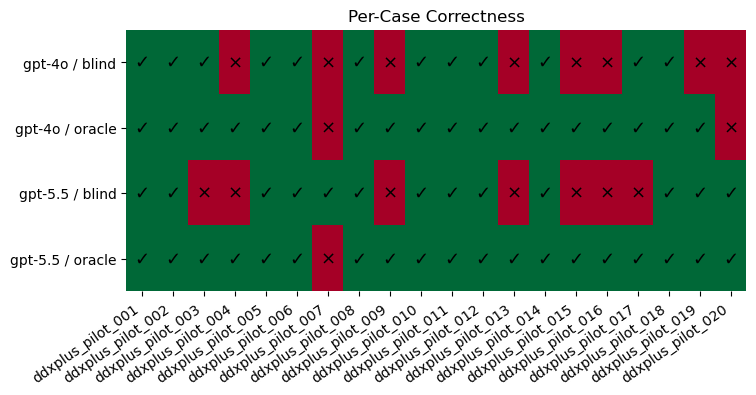

In [13]:
case_order = list(smoke_cases['case_id'])
row_labels = [f'{m} / {c}' for m in models for c in conditions]
heatmap = []
for model in models:
    for condition in conditions:
        vals = (
            baseline_results[(baseline_results['model'] == model) & (baseline_results['condition'] == condition)]
            .set_index('case_id')
            .reindex(case_order)['is_correct']
            .astype(int)
            .to_numpy()
        )
        heatmap.append(vals)
heatmap = np.array(heatmap)

fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(heatmap, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(len(case_order)))
ax.set_xticklabels(case_order, rotation=35, ha='right')
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_title('Per-Case Correctness')
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        ax.text(j, i, '✓' if heatmap[i, j] else '×', ha='center', va='center', color='black', fontsize=13)
ax.spines[:].set_visible(False)
plt.show()


### Inspect The Prompts Without Answer Leakage

These checks make the visibility rule explicit: blind prompts contain only the question and options; oracle prompts additionally contain `evidence`; neither prompt contains hidden metadata column names or probability values.

The true pathology and top differential names are intentionally not treated as hidden string values in this check, because they are the visible diagnosis options.


In [14]:
example_row = smoke_cases.iloc[0]
for condition in conditions:
    prompt_text = '\n\n'.join(message['content'] for message in build_baseline_prompt(example_row, condition))
    hidden_column_names = [
        'correct_answer',
        'pathology',
        'top_differential',
        'pathology_probability',
        'top_differential_probability',
    ]
    hidden_probability_values = [
        str(example_row['pathology_probability']),
        str(example_row['top_differential_probability']),
    ]
    print(condition)
    print('contains evidence:', str(example_row['evidence'][:80]) in prompt_text)
    print('contains hidden metadata column names:', any(name in prompt_text for name in hidden_column_names))
    print('contains hidden probability values:', any(value and value in prompt_text for value in hidden_probability_values))
    print(prompt_text[:900])
    print('-' * 80)


blind
contains evidence: False
contains hidden metadata column names: False
contains hidden probability values: False
You are a careful medical diagnosis judge in an academic benchmark. Pick only from the provided options.

You are answering a two-option medical diagnosis question.
You will see only the presenting question stem and two possible diagnoses. You will not see the full patient evidence.

Question: A 39-year-old female patient presents with hoarse or softer voice. What is the most likely diagnosis?

A: Acute laryngitis
B: Bronchitis

Choose the diagnosis you think is most likely to be correct. You must choose exactly one option, A or B. Reply in this exact format and nothing else:
Answer: A

If you think option B is correct, reply exactly:
Answer: B
--------------------------------------------------------------------------------
oracle
contains evidence: True
contains hidden metadata column names: False
contains hidden probability values: False
You are a careful medical diag

## Pipeline-Backed Baseline (`core.judge`)

This section replaces the hand-rolled API loop above with results produced by the project's actual pipeline (`core.debate` -> `core.judge` -> `core.scoring.accuracy`). That way every later experiment (debate arms, BoN sweep, etc.) reuses the same code path and the baseline numbers stay directly comparable.

To produce the inputs for this section, run from the repo root:

```bash
source .venv/bin/activate
./scripts/run_medical_baselines_test5.sh   # 5-case smoke
# or, for the full pilot:
./scripts/run_medical_baselines.sh         # 100 cases
```

The cells below just read the resulting CSVs. They do **not** call the OpenAI API. The judge model is whatever is configured in `core/config/experiment/judge/baselines/medical_*.yaml` (currently `gpt-4o-mini`). Override with e.g. `++judge.language_model.model=...` on the shell command if you want a different judge.


In [ ]:
from pathlib import Path
import pandas as pd

# Point this at whichever exp_dir you ran the shell script with.
PIPELINE_EXP_DIR = Path('exp/medical_pilot_test5')

def load_pipeline_arm(exp_dir: Path, arm: str) -> pd.DataFrame:
    """Load the judged CSV for one arm (baseline_blind or baseline_oracle)."""
    csv_path = exp_dir / arm / 'data0.csv'
    if not csv_path.exists():
        raise FileNotFoundError(
            f'{csv_path} not found. Run ./scripts/run_medical_baselines_test5.sh first '
            f'(or set PIPELINE_EXP_DIR to a directory you have already populated).'
        )
    df = pd.read_csv(csv_path)
    df = df[df['complete'] == True].copy()
    df['arm'] = arm
    df['is_correct'] = df['answer'].astype(str).str.strip() == df['correct answer'].astype(str).str.strip()
    return df

pipeline_blind = load_pipeline_arm(PIPELINE_EXP_DIR, 'baseline_blind')
pipeline_oracle = load_pipeline_arm(PIPELINE_EXP_DIR, 'baseline_oracle')
pipeline_results = pd.concat([pipeline_blind, pipeline_oracle], ignore_index=True)
pipeline_results[['id', 'arm', 'correct answer', 'negative answer', 'answer', 'is_correct']].head(10)


In [ ]:
pipeline_summary = (
    pipeline_results
    .groupby('arm', as_index=False)
    .agg(n=('id', 'count'), accuracy=('is_correct', 'mean'),
         invalid=('answer', lambda s: s.isna().sum() + (s.astype(str).str.strip() == '').sum()))
)
pipeline_summary['accuracy_pct'] = (pipeline_summary['accuracy'] * 100).round(1)
pipeline_summary[['arm', 'n', 'accuracy_pct', 'invalid']]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5.5, 4))
arms_order = ['baseline_blind', 'baseline_oracle']
colors = {'baseline_blind': '#4C78A8', 'baseline_oracle': '#F58518'}
vals = pipeline_summary.set_index('arm').reindex(arms_order)['accuracy_pct']
bars = ax.bar(np.arange(len(arms_order)), vals, color=[colors[a] for a in arms_order])
ax.bar_label(bars, labels=[f'{v:.0f}%' for v in vals], padding=3)
ax.set_xticks(np.arange(len(arms_order)))
ax.set_xticklabels([a.replace('baseline_', '').title() for a in arms_order])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.set_title(f'Pipeline Baselines ({PIPELINE_EXP_DIR.name}, n={pipeline_summary["n"].iloc[0]})')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
plt.show()
